In [1]:

import requests
import json
import os
import time
from datetime import datetime


TOP_STORIES_URL = "https://hacker-news.firebaseio.com/v0/topstories.json"
ITEM_URL = "https://hacker-news.firebaseio.com/v0/item/{}.json"
HEADERS = {"User-Agent": "TrendPulse/1.0"}

MAX_STORIES_TO_FETCH = 500   # how many top story IDs to pull
MAX_PER_CATEGORY = 25        # cap per category (5 categories x 25 = 125 max)

# Keywords used to assign each story to a category (case-insensitive).
# Order matters: a story is assigned to the FIRST category whose keyword
# it matches.
CATEGORY_KEYWORDS = {
    "technology": ["ai", "software", "tech", "code", "computer", "data", "cloud", "api", "gpu", "llm"],
    "worldnews": ["war", "government", "country", "president", "election", "climate", "attack", "global"],
    "sports": ["nfl", "nba", "fifa", "sport", "game", "team", "player", "league", "championship"],
    "science": ["research", "study", "space", "physics", "biology", "discovery", "nasa", "genome"],
    "entertainment": ["movie", "film", "music", "netflix", "game", "book", "show", "award", "streaming"],
}


def get_top_story_ids():
    """Fetch the list of top story IDs and return the first MAX_STORIES_TO_FETCH of them."""
    response = requests.get(TOP_STORIES_URL, headers=HEADERS, timeout=10)
    response.raise_for_status()
    story_ids = response.json()
    return story_ids[:MAX_STORIES_TO_FETCH]


def get_story_details(story_id):
    """Fetch a single story's details. Returns None (and prints a message) on failure."""
    try:
        response = requests.get(ITEM_URL.format(story_id), headers=HEADERS, timeout=10)
        response.raise_for_status()
        return response.json()
    except requests.RequestException as e:
        print(f"  ! Failed to fetch story {story_id}: {e}")
        return None


def categorize(title):
    """Return the first category whose keyword appears in the title, or None."""
    title_lower = title.lower()
    for category, keywords in CATEGORY_KEYWORDS.items():
        for keyword in keywords:
            if keyword.lower() in title_lower:
                return category
    return None


def main():
    print("Fetching top story IDs...")
    story_ids = get_top_story_ids()
    print(f"Got {len(story_ids)} story IDs. Fetching details...")

    # Fetch every story's details ONCE and cache it. This avoids re-fetching
    # the same story 5 times (once per category) later on.
    story_cache = {}
    for story_id in story_ids:
        details = get_story_details(story_id)
        if details is None:
            continue  # request failed - skip and move on, per spec
        story_cache[story_id] = details

    collected = []

    for category in CATEGORY_KEYWORDS:
        count = 0
        for story_id, story in story_cache.items():
            if count >= MAX_PER_CATEGORY:
                break

            title = story.get("title", "")
            if not title:
                continue

            assigned_category = categorize(title)
            if assigned_category == category:
                collected.append({
                    "post_id": story.get("id"),
                    "title": title,
                    "category": category,
                    "score": story.get("score", 0),
                    "num_comments": story.get("descendants", 0),
                    "author": story.get("by", "unknown"),
                    "collected_at": datetime.now().isoformat(),
                })
                count += 1

        print(f"  Collected {count} stories for category '{category}'")
        time.sleep(2)  # required 2-second pause between category loops

    os.makedirs("data", exist_ok=True)
    filename = f"data/trends_{datetime.now().strftime('%Y%m%d')}.json"
    with open(filename, "w") as f:
        json.dump(collected, f, indent=2)

    print(f"Collected {len(collected)} stories. Saved to {filename}")


if __name__ == "__main__":
    main()

Fetching top story IDs...
Got 500 story IDs. Fetching details...
  Collected 25 stories for category 'technology'
  Collected 14 stories for category 'worldnews'
  Collected 12 stories for category 'sports'
  Collected 7 stories for category 'science'
  Collected 25 stories for category 'entertainment'
Collected 83 stories. Saved to data/trends_20260901.json


In [2]:

import pandas as pd
import glob
import os


def load_data():
    """Find the most recent trends_*.json file in data/ and load it into a DataFrame."""
    json_files = glob.glob("data/trends_*.json")
    if not json_files:
        raise FileNotFoundError(
            "No data/trends_*.json file found. Run task1_data_collection.py first."
        )


    latest_file = max(json_files, key=os.path.getmtime)

    df = pd.read_json(latest_file)
    print(f"Loaded {len(df)} stories from {latest_file}")
    return df


def clean_data(df):
    # 1. Duplicates -- remove any rows with the same post_id
    df = df.drop_duplicates(subset="post_id")
    print(f"After removing duplicates: {len(df)}")

    # 2. Missing values -- drop rows where post_id, title, or score is missing
    df = df.dropna(subset=["post_id", "title", "score"])
    print(f"After removing nulls: {len(df)}")

    # 3. Data types -- make sure score and num_comments are integers
    df["score"] = df["score"].astype(int)
    df["num_comments"] = df["num_comments"].astype(int)

    # 4. Low quality -- remove stories where score is less than 5
    df = df[df["score"] >= 5]
    print(f"After removing low scores: {len(df)}")

    # 5. Whitespace -- strip extra spaces from the title column
    df["title"] = df["title"].str.strip()

    return df


def save_clean_csv(df):
    os.makedirs("data", exist_ok=True)
    output_path = "data/trends_clean.csv"
    df.to_csv(output_path, index=False)
    print(f"\nSaved {len(df)} rows to {output_path}")

    print("\nStories per category:")
    print(df["category"].value_counts().to_string())


def main():
    df = load_data()
    print()  # blank line, matches expected output spacing
    df_clean = clean_data(df)
    save_clean_csv(df_clean)


if __name__ == "__main__":
    main()

Loaded 83 stories from data/trends_20260901.json

After removing duplicates: 83
After removing nulls: 83
After removing low scores: 80

Saved 80 rows to data/trends_clean.csv

Stories per category:
category
technology       24
entertainment    24
worldnews        14
sports           11
science           7


In [3]:


import pandas as pd
import numpy as np


def load_and_explore():
    df = pd.read_csv("data/trends_clean.csv")

    print(f"Loaded data: {df.shape}")

    print("\nFirst 5 rows:")
    print(df.head())

    avg_score = df["score"].mean()
    avg_comments = df["num_comments"].mean()
    print(f"\nAverage score   : {avg_score:,.0f}")
    print(f"Average comments: {avg_comments:,.0f}")

    return df


def numpy_analysis(df):
    scores = df["score"].to_numpy()

    mean_score = np.mean(scores)
    median_score = np.median(scores)
    std_score = np.std(scores)
    max_score = np.max(scores)
    min_score = np.min(scores)

    print("\n--- NumPy Stats ---")
    print(f"Mean score    : {mean_score:,.0f}")
    print(f"Median score  : {median_score:,.0f}")
    print(f"Std deviation : {std_score:,.0f}")
    print(f"Max score     : {max_score:,.0f}")
    print(f"Min score     : {min_score:,.0f}")

    # Category with the most stories
    top_category = df["category"].value_counts().idxmax()
    top_category_count = df["category"].value_counts().max()
    print(f"\nMost stories in: {top_category} ({top_category_count} stories)")

    # Story with the most comments
    top_story = df.loc[df["num_comments"].idxmax()]
    print(f'Most commented story: "{top_story["title"]}" - {top_story["num_comments"]:,} comments')


def add_new_columns(df):
    # engagement: how much discussion a story gets per upvote
    df["engagement"] = df["num_comments"] / (df["score"] + 1)

    # is_popular: True if score is above the average score, else False
    avg_score = df["score"].mean()
    df["is_popular"] = df["score"] > avg_score

    return df


def save_result(df):
    output_path = "data/trends_analysed.csv"
    df.to_csv(output_path, index=False)
    print(f"\nSaved to {output_path}")



def main():
    df = load_and_explore()
    numpy_analysis(df)
    df = add_new_columns(df)
    save_result(df)


if __name__ == "__main__":
    main()

Loaded data: (80, 7)

First 5 rows:
    post_id                                              title    category  \
0  49517584                                          GPU World  technology   
1  49503521  Terence Tao explains 6 essential mathematical ...  technology   
2  49508982  Apple caught off guard by AI demand for Mac Mi...  technology   
3  49496292      Smartphone LED detects hidden cameras with AI  technology   
4  49515830                        Run macOS Software on Linux  technology   

   score  num_comments           author                collected_at  
0     53            10        simonpure  2026-09-01 05:59:21.378533  
1    339            39  matthewsinclair  2026-09-01 05:59:21.378621  
2    368           416              thm  2026-09-01 05:59:21.378679  
3    187            54             geox  2026-09-01 05:59:21.378717  
4    190            62        Bluestein  2026-09-01 05:59:21.378732  

Average score   : 117
Average comments: 57

--- NumPy Stats ---
Mean score

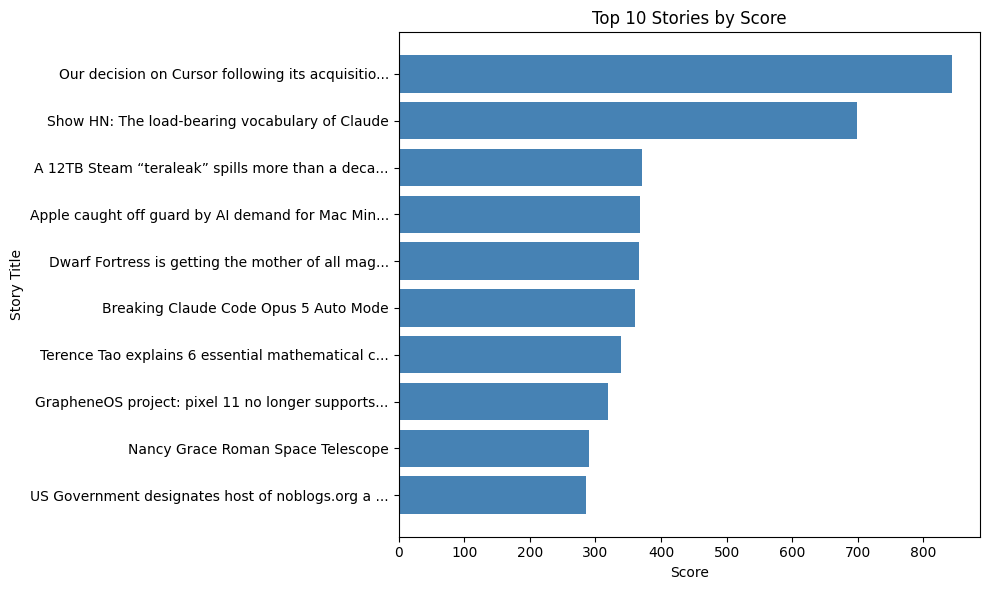

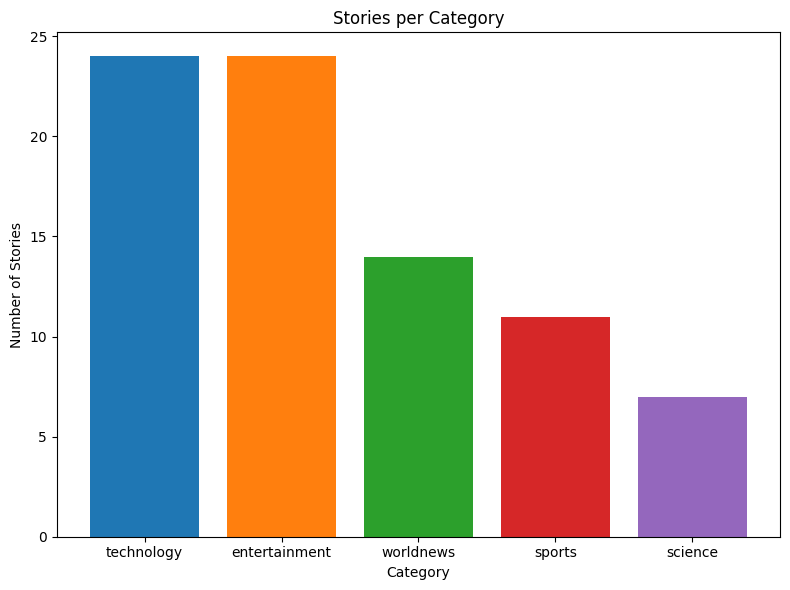

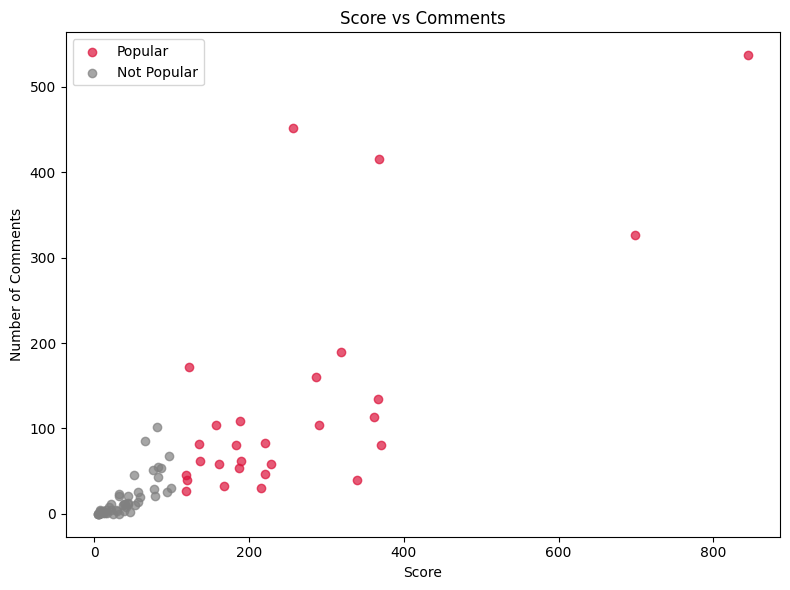

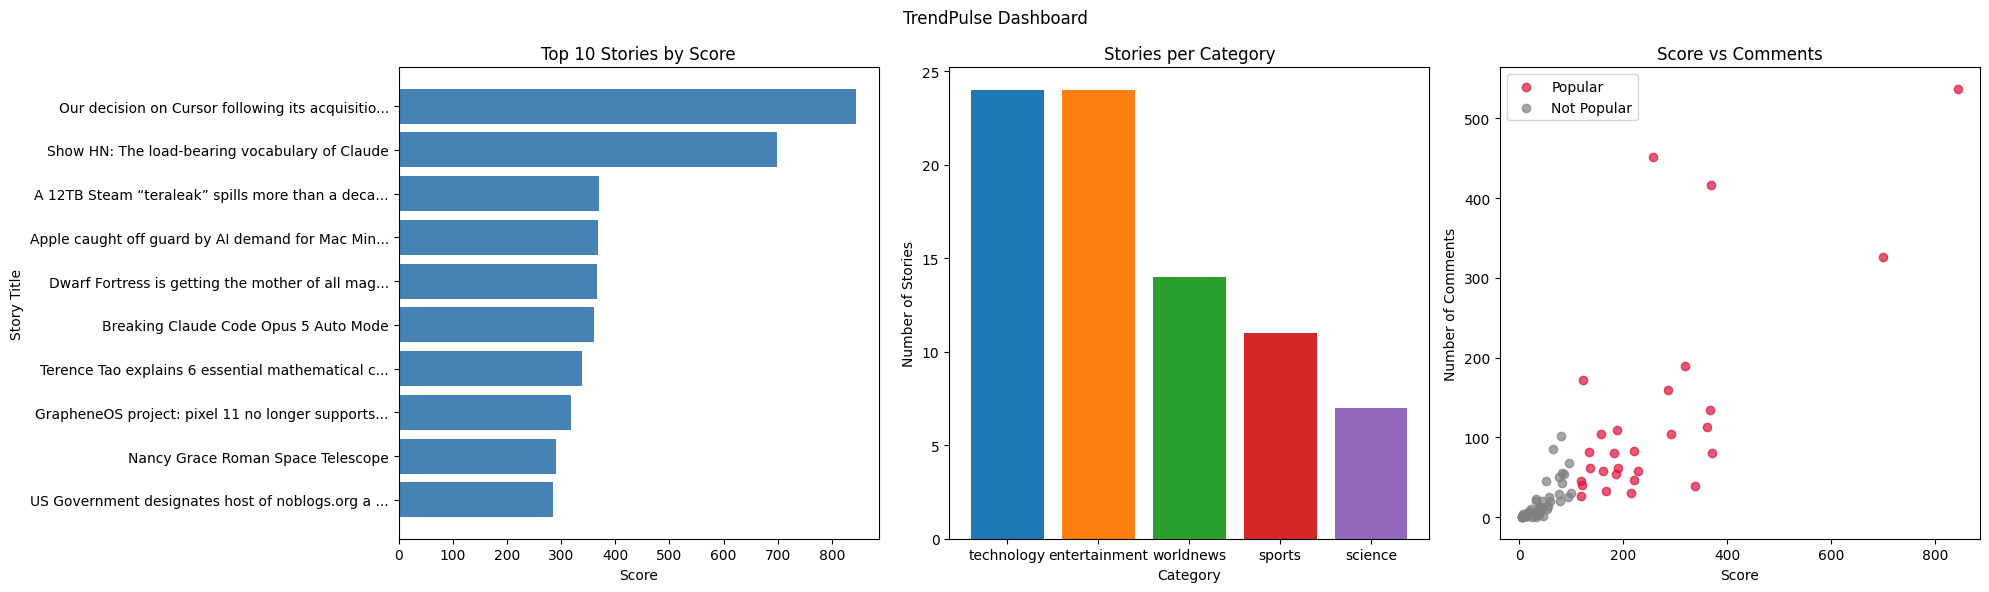

Saved: outputs/chart1_top_stories.png, chart2_categories.png, chart3_scatter.png, dashboard.png


In [4]:

import matplotlib.pyplot as plt




def load_data():
    df = pd.read_csv("data/trends_analysed.csv")
    os.makedirs("outputs", exist_ok=True)
    return df


def shorten_title(title, max_len=50):
    """Shorten titles longer than max_len characters, adding '...'."""
    if len(title) > max_len:
        return title[:max_len - 3] + "..."
    return title



def chart1_top_stories(df):
    top10 = df.sort_values("score", ascending=False).head(10)
    # sort ascending for the plot so the highest score ends up at the top of the barh
    top10 = top10.sort_values("score", ascending=True)

    labels = [shorten_title(t) for t in top10["title"]]

    plt.figure(figsize=(10, 6))
    plt.barh(labels, top10["score"], color="steelblue")
    plt.title("Top 10 Stories by Score")
    plt.xlabel("Score")
    plt.ylabel("Story Title")
    plt.tight_layout()
    plt.savefig("outputs/chart1_top_stories.png")
    plt.show()


def chart2_categories(df):
    counts = df["category"].value_counts()

    plt.figure(figsize=(8, 6))
    colors = plt.cm.tab10.colors[:len(counts)]
    plt.bar(counts.index, counts.values, color=colors)
    plt.title("Stories per Category")
    plt.xlabel("Category")
    plt.ylabel("Number of Stories")
    plt.tight_layout()
    plt.savefig("outputs/chart2_categories.png")
    plt.show()


def chart3_scatter(df):
    popular = df[df["is_popular"] == True]
    not_popular = df[df["is_popular"] == False]

    plt.figure(figsize=(8, 6))
    plt.scatter(popular["score"], popular["num_comments"],
                color="crimson", label="Popular", alpha=0.7)
    plt.scatter(not_popular["score"], not_popular["num_comments"],
                color="gray", label="Not Popular", alpha=0.7)
    plt.title("Score vs Comments")
    plt.xlabel("Score")
    plt.ylabel("Number of Comments")
    plt.legend()
    plt.tight_layout()
    plt.savefig("outputs/chart3_scatter.png")
    plt.show()


def dashboard(df):
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Panel 1: Top 10 stories by score
    top10 = df.sort_values("score", ascending=False).head(10)
    top10 = top10.sort_values("score", ascending=True)
    labels = [shorten_title(t) for t in top10["title"]]
    axes[0].barh(labels, top10["score"], color="steelblue")
    axes[0].set_title("Top 10 Stories by Score")
    axes[0].set_xlabel("Score")
    axes[0].set_ylabel("Story Title")

    # Panel 2: Stories per category
    counts = df["category"].value_counts()
    colors = plt.cm.tab10.colors[:len(counts)]
    axes[1].bar(counts.index, counts.values, color=colors)
    axes[1].set_title("Stories per Category")
    axes[1].set_xlabel("Category")
    axes[1].set_ylabel("Number of Stories")

    # Panel 3: Score vs comments
    popular = df[df["is_popular"] == True]
    not_popular = df[df["is_popular"] == False]
    axes[2].scatter(popular["score"], popular["num_comments"],
                     color="crimson", label="Popular", alpha=0.7)
    axes[2].scatter(not_popular["score"], not_popular["num_comments"],
                     color="gray", label="Not Popular", alpha=0.7)
    axes[2].set_title("Score vs Comments")
    axes[2].set_xlabel("Score")
    axes[2].set_ylabel("Number of Comments")
    axes[2].legend()

    fig.suptitle("TrendPulse Dashboard")
    plt.tight_layout()
    plt.savefig("outputs/dashboard.png")
    plt.show()


def main():
    df = load_data()
    chart1_top_stories(df)
    chart2_categories(df)
    chart3_scatter(df)
    dashboard(df)
    print("Saved: outputs/chart1_top_stories.png, chart2_categories.png, "
          "chart3_scatter.png, dashboard.png")


if __name__ == "__main__":
    main()